# GeoMind AI — Model Training

Classical ML pipeline for traffic forecasting.  
Models are evaluated on the **validation set** only. Test set is held out.

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import time
import json
import joblib
import warnings
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load Data

In [4]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df   = pd.read_csv('../data/processed/val.csv')

with open('../data/processed/feature_config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['features']
TARGET_COL   = config['target']

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET_COL]

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

Train: (42, 29)  |  Val: (9, 29)


## 3. Evaluation Helper

In [9]:
def evaluate(name, y_true, y_pred, train_time, infer_time):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {
        'Model': name,
        'MAE':   round(mae, 2),
        'RMSE':  round(rmse, 2),
        'R2':    round(r2, 4),
        'Train_Time_s':  round(train_time, 3),
        'Infer_Time_ms': round(infer_time * 1000, 2)
    }

results = []
models  = {}

## 4. Baseline: Historical Mean

In [10]:
train_mean = y_train.mean()
pred_mean  = np.full(len(y_val), train_mean)

results.append(evaluate('Historical Mean', y_val, pred_mean, 0.0, 0.0))
print(results[-1])

{'Model': 'Historical Mean', 'MAE': 151.08, 'RMSE': np.float64(183.9), 'R2': -0.033, 'Train_Time_s': 0.0, 'Infer_Time_ms': 0.0}


## 5. Baseline: Persistence (lag_1)

In [11]:
pred_persistence = val_df['lag_1'].values

results.append(evaluate('Persistence', y_val, pred_persistence, 0.0, 0.0))
print(results[-1])

{'Model': 'Persistence', 'MAE': 838.0, 'RMSE': np.float64(853.48), 'R2': -21.2495, 'Train_Time_s': 0.0, 'Infer_Time_ms': 0.0}


## 6. Linear Regression

In [12]:
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_lr = lr.predict(X_val)
infer_time = time.time() - t0

models['Linear Regression'] = lr
results.append(evaluate('Linear Regression', y_val, pred_lr, train_time, infer_time))
print(results[-1])

{'Model': 'Linear Regression', 'MAE': 237.92, 'RMSE': np.float64(289.47), 'R2': -1.5594, 'Train_Time_s': 0.056, 'Infer_Time_ms': 5.0}


## 7. Ridge Regression

In [13]:
t0 = time.time()
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_ridge = ridge.predict(X_val)
infer_time = time.time() - t0

models['Ridge Regression'] = ridge
results.append(evaluate('Ridge Regression', y_val, pred_ridge, train_time, infer_time))
print(results[-1])

{'Model': 'Ridge Regression', 'MAE': 198.29, 'RMSE': np.float64(237.42), 'R2': -0.7217, 'Train_Time_s': 0.049, 'Infer_Time_ms': 7.07}


## 8. Decision Tree

In [14]:
t0 = time.time()
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_dt = dt.predict(X_val)
infer_time = time.time() - t0

models['Decision Tree'] = dt
results.append(evaluate('Decision Tree', y_val, pred_dt, train_time, infer_time))
print(results[-1])

{'Model': 'Decision Tree', 'MAE': 130.12, 'RMSE': np.float64(159.98), 'R2': 0.2182, 'Train_Time_s': 0.046, 'Infer_Time_ms': 2.0}


## 9. Random Forest

In [15]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_rf = rf.predict(X_val)
infer_time = time.time() - t0

models['Random Forest'] = rf
results.append(evaluate('Random Forest', y_val, pred_rf, train_time, infer_time))
print(results[-1])

{'Model': 'Random Forest', 'MAE': 111.78, 'RMSE': np.float64(133.01), 'R2': 0.4596, 'Train_Time_s': 0.229, 'Infer_Time_ms': 32.14}


## 10. Gradient Boosting

In [16]:
t0 = time.time()
gb = GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_gb = gb.predict(X_val)
infer_time = time.time() - t0

models['Gradient Boosting'] = gb
results.append(evaluate('Gradient Boosting', y_val, pred_gb, train_time, infer_time))
print(results[-1])

{'Model': 'Gradient Boosting', 'MAE': 105.01, 'RMSE': np.float64(140.51), 'R2': 0.397, 'Train_Time_s': 0.47, 'Infer_Time_ms': 8.66}


## 11. XGBoost

In [17]:
t0 = time.time()
xgb = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   n_jobs=-1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
train_time = time.time() - t0

t0 = time.time()
pred_xgb = xgb.predict(X_val)
infer_time = time.time() - t0

models['XGBoost'] = xgb
results.append(evaluate('XGBoost', y_val, pred_xgb, train_time, infer_time))
print(results[-1])

{'Model': 'XGBoost', 'MAE': 83.87, 'RMSE': np.float64(122.9), 'R2': 0.5386, 'Train_Time_s': 0.585, 'Infer_Time_ms': 7.15}


## 12. Results Comparison

In [18]:
results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,MAE,RMSE,R2,Train_Time_s,Infer_Time_ms
7,XGBoost,83.87,122.90,0.5386,0.585,7.15
5,Random Forest,111.78,133.01,0.4596,0.229,32.14
6,Gradient Boosting,105.01,140.51,0.3970,0.470,8.66
4,Decision Tree,130.12,159.98,0.2182,0.046,2.00
0,Historical Mean,151.08,183.90,-0.0330,0.000,0.00
3,Ridge Regression,198.29,237.42,-0.7217,0.049,7.07
2,Linear Regression,237.92,289.47,-1.5594,0.056,5.00
1,Persistence,838.00,853.48,-21.2495,0.000,0.00


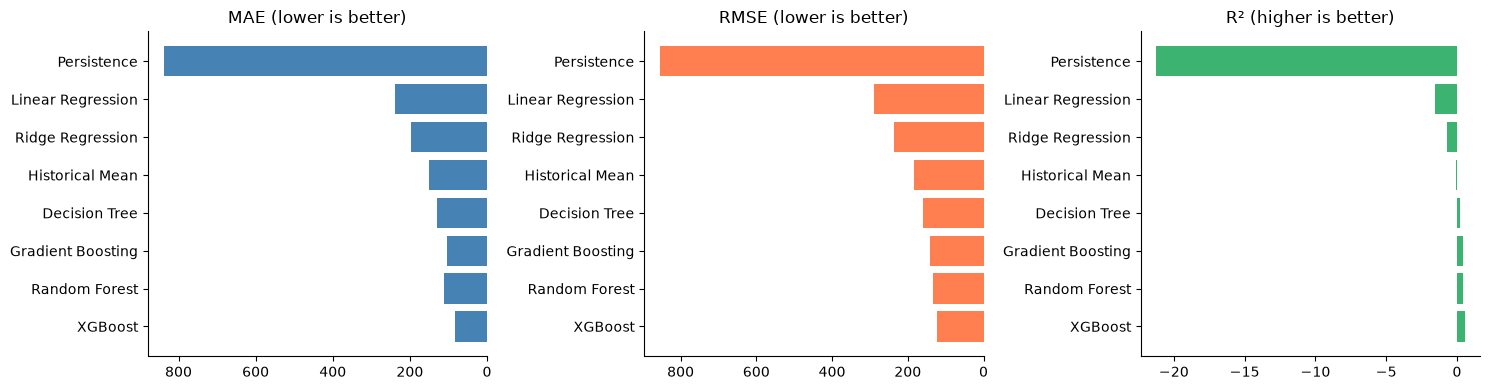

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_sorted = results_df['Model']

axes[0].barh(results_df['Model'], results_df['MAE'], color='steelblue')
axes[0].set_title('MAE (lower is better)')
axes[0].invert_xaxis()

axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_title('RMSE (lower is better)')
axes[1].invert_xaxis()

axes[2].barh(results_df['Model'], results_df['R2'], color='mediumseagreen')
axes[2].set_title('R² (higher is better)')

plt.tight_layout()
plt.show()

## 13. Save Models

In [20]:
import os
os.makedirs('../models', exist_ok=True)

for name, model in models.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'../models/{fname}')
    print(f"Saved: {fname}")

results_df.to_csv('../models/val_results.csv', index=False)
print("\nSaved: val_results.csv")

Saved: linear_regression.pkl
Saved: ridge_regression.pkl
Saved: decision_tree.pkl
Saved: random_forest.pkl
Saved: gradient_boosting.pkl
Saved: xgboost.pkl

Saved: val_results.csv


## 14. Best Model on Validation

In [21]:
best = results_df.iloc[0]
print(f"Best model (by RMSE): {best['Model']}")
print(f"  MAE  = {best['MAE']}")
print(f"  RMSE = {best['RMSE']}")
print(f"  R²   = {best['R2']}")

Best model (by RMSE): XGBoost
  MAE  = 83.87
  RMSE = 122.9
  R²   = 0.5386
